# Exploratory: Probe ALL RDKit Descriptors

## Objective
Instead of focusing on just 10 drug-likeness descriptors, let's probe **ALL ~200 RDKit molecular descriptors** to discover:
- Which molecular properties are best encoded in SSL embeddings?
- Are there surprising descriptors with high R²?
- Which descriptor categories work best (size, shape, electronic, topological)?

## Approach
1. Calculate ALL available RDKit descriptors (~209 total)
2. Train simple linear probes for each
3. Rank by R² score
4. Analyze patterns: What makes a descriptor "learnable" from spectra?

## Expected Runtime
- Descriptor calculation: ~30-60 min (231k molecules)
- Probing (Linear only): ~30-60 min (209 descriptors × 30 epochs)
- **Total: ~1-2 hours**

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import pickle

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

# Random seeds
np.random.seed(42)
torch.manual_seed(42)

print("✓ Imports complete")

✓ Imports complete


## 2. Get ALL RDKit Descriptors

RDKit has ~209 molecular descriptors across categories:
- **Constitutional**: Basic counts (atoms, bonds, rings)
- **Topological**: Graph properties (Wiener, Zagreb indices)
- **Electronic**: Charge, electronegativity
- **Geometric**: Shape, surface area, volume
- **Pharmacophore**: Drug-likeness (Lipinski, QED)
- **Fragment-based**: Functional group counts

In [2]:
# Get all descriptor names
descriptor_names = [desc[0] for desc in Descriptors.descList]

print(f"Total RDKit Descriptors: {len(descriptor_names)}")
print(f"\nFirst 20 descriptors:")
for i, name in enumerate(descriptor_names[:20], 1):
    print(f"  {i:3d}. {name}")

print(f"\n... (showing 20/{len(descriptor_names)})")

Total RDKit Descriptors: 208

First 20 descriptors:
    1. MaxEStateIndex
    2. MinEStateIndex
    3. MaxAbsEStateIndex
    4. MinAbsEStateIndex
    5. qed
    6. MolWt
    7. HeavyAtomMolWt
    8. ExactMolWt
    9. NumValenceElectrons
   10. NumRadicalElectrons
   11. MaxPartialCharge
   12. MinPartialCharge
   13. MaxAbsPartialCharge
   14. MinAbsPartialCharge
   15. FpDensityMorgan1
   16. FpDensityMorgan2
   17. FpDensityMorgan3
   18. BCUT2D_MWHI
   19. BCUT2D_MWLOW
   20. BCUT2D_CHGHI

... (showing 20/208)


## 3. Load MassSpecGym Dataset

In [4]:
# Load dataset with SSL embeddings and Murcko splits
data_path = Path('../../data/processed/massspecgym_complete/ssl_embs/MassSpecGym_with_SSL_embeddings_murcko_hist_splits.parquet')
df = pd.read_parquet(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFold distribution:")
print(df['fold'].value_counts())
print(f"\nColumns: {df.columns.tolist()[:10]}... (showing first 10)")

Dataset shape: (231104, 30)

Fold distribution:
fold
train    159271
test      45185
val       26648
Name: count, dtype: int64

Columns: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct']... (showing first 10)


## 4. Calculate ALL RDKit Descriptors

**Note**: This will take ~30-60 minutes for 231k molecules.

We'll:
1. Calculate descriptors for unique SMILES only (not all spectra)
2. Save results to avoid recomputation
3. Filter out NaN/Inf values
4. Merge back to full dataset

In [6]:
# Check if descriptors already calculated
descriptors_cache_path = Path('../../data/processed/massspecgym_complete/all_rdkit_descriptors.parquet')

if descriptors_cache_path.exists():
    print("✓ Loading cached descriptors...")
    df_descriptors = pd.read_parquet(descriptors_cache_path)
    print(f"  Loaded {len(df_descriptors):,} molecules with {len(df_descriptors.columns)-1} descriptors")
else:
    print("Calculating ALL RDKit descriptors...")
    print("⏱️  This will take ~30-60 minutes\n")
    
    # Get unique SMILES
    df_unique = df[['smiles']].drop_duplicates().copy()
    print(f"Unique molecules: {len(df_unique):,}")
    
    # Initialize descriptor calculator
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
    
    # Calculate descriptors
    results = []
    failed = 0
    
    for idx, row in tqdm(df_unique.iterrows(), total=len(df_unique), desc="Computing descriptors"):
        smiles = row['smiles']
        mol = Chem.MolFromSmiles(smiles)
        
        if mol is None:
            failed += 1
            results.append([smiles] + [np.nan] * len(descriptor_names))
        else:
            try:
                desc_values = calc.CalcDescriptors(mol)
                results.append([smiles] + list(desc_values))
            except Exception as e:
                failed += 1
                results.append([smiles] + [np.nan] * len(descriptor_names))
    
    # Create DataFrame
    df_descriptors = pd.DataFrame(results, columns=['smiles'] + descriptor_names)
    
    print(f"\n✓ Calculation complete!")
    print(f"  Failed: {failed}/{len(df_unique)} molecules")
    
    # Save cache
    descriptors_cache_path.parent.mkdir(parents=True, exist_ok=True)
    df_descriptors.to_parquet(descriptors_cache_path, index=False)
    print(f"  Saved cache to: {descriptors_cache_path.name}")

Calculating ALL RDKit descriptors...
⏱️  This will take ~30-60 minutes

Unique molecules: 31,602


Computing descriptors: 100%|██████████| 31602/31602 [07:51<00:00, 66.97it/s] 




✓ Calculation complete!
  Failed: 0/31602 molecules
  Saved cache to: all_rdkit_descriptors.parquet


## 5. Filter Valid Descriptors

Remove descriptors with:
- Too many NaN values (>10%)
- Inf values
- Zero variance (constant)

In [7]:
print("Filtering descriptors...")

valid_descriptors = []
invalid_reasons = {}

for desc in descriptor_names:
    if desc not in df_descriptors.columns:
        continue
    
    values = df_descriptors[desc]
    
    # Check NaN percentage
    nan_pct = values.isna().sum() / len(values)
    if nan_pct > 0.1:
        invalid_reasons[desc] = f"Too many NaN ({nan_pct*100:.1f}%)"
        continue
    
    # Check for Inf
    if np.isinf(values.dropna()).any():
        invalid_reasons[desc] = "Contains Inf"
        continue
    
    # Check variance
    if values.dropna().std() == 0:
        invalid_reasons[desc] = "Zero variance (constant)"
        continue
    
    valid_descriptors.append(desc)

print(f"\nValid descriptors: {len(valid_descriptors)}/{len(descriptor_names)}")
print(f"Removed: {len(invalid_reasons)}")

if len(invalid_reasons) > 0:
    print(f"\nRemoval reasons (showing first 10):")
    for desc, reason in list(invalid_reasons.items())[:10]:
        print(f"  {desc}: {reason}")

Filtering descriptors...

Valid descriptors: 201/208
Removed: 7

Removal reasons (showing first 10):
  NumRadicalElectrons: Zero variance (constant)
  MaxPartialCharge: Contains Inf
  MaxAbsPartialCharge: Contains Inf
  SMR_VSA8: Zero variance (constant)
  SlogP_VSA9: Zero variance (constant)
  fr_diazo: Zero variance (constant)
  fr_prisulfonamd: Zero variance (constant)


## 6. Merge Descriptors with Dataset

In [13]:
# Check for overlapping columns and drop old descriptor columns before merge
print("Checking for overlapping columns...")
old_descriptor_cols = ['alogp', 'hba', 'hbd', 'tpsa', 'n_rotatable_bonds', 
                       'n_aromatic_rings', 'n_aliphatic_rings', 'fsp3', 'qed', 'sa_score']
existing_overlap = [col for col in old_descriptor_cols if col in df.columns]

if existing_overlap:
    print(f"⚠️  Found {len(existing_overlap)} overlapping descriptor columns: {existing_overlap}")
    print(f"   Dropping old columns to avoid merge conflicts...")
    df_clean = df.drop(columns=existing_overlap)
else:
    print("✓ No overlapping columns found")
    df_clean = df

# Merge valid descriptors only
df_with_descriptors = df_clean.merge(
    df_descriptors[['smiles'] + valid_descriptors],
    on='smiles',
    how='left'
)

print(f"\nMerged dataset shape: {df_with_descriptors.shape}")
print(f"Added {len(valid_descriptors)} descriptors")

# Verify qed column
if 'qed' in df_with_descriptors.columns:
    print("✓ 'qed' column present and ready to use")
else:
    qed_cols = [col for col in df_with_descriptors.columns if 'qed' in col.lower()]
    print(f"⚠️  'qed' not found, but found: {qed_cols}")

# Split by fold
df_train = df_with_descriptors[df_with_descriptors['fold'] == 'train'].copy()
df_test = df_with_descriptors[df_with_descriptors['fold'] == 'test'].copy()

print(f"\nSplit sizes:")
print(f"  Train: {len(df_train):,}")
print(f"  Test:  {len(df_test):,}")

Checking for overlapping columns...
⚠️  Found 10 overlapping descriptor columns: ['alogp', 'hba', 'hbd', 'tpsa', 'n_rotatable_bonds', 'n_aromatic_rings', 'n_aliphatic_rings', 'fsp3', 'qed', 'sa_score']
   Dropping old columns to avoid merge conflicts...

Merged dataset shape: (231104, 221)
Added 201 descriptors
✓ 'qed' column present and ready to use

Merged dataset shape: (231104, 221)
Added 201 descriptors
✓ 'qed' column present and ready to use

Split sizes:
  Train: 159,271
  Test:  45,185

Split sizes:
  Train: 159,271
  Test:  45,185


## 7. Define Probe Model

Use **simple Linear probe only** for speed.
- 209 descriptors × 30 epochs × Linear = ~30-60 min
- Adding MLP would double the time

In [14]:
class LinearProbe(nn.Module):
    """Simple linear regression probe"""
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)


class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, targets):
        self.embeddings = torch.FloatTensor(embeddings)
        self.targets = torch.FloatTensor(targets).unsqueeze(1)
    
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.targets[idx]


def train_probe(X_train, y_train, X_test, y_test, epochs=30, lr=0.001, device='cpu'):
    """
    Train linear probe and evaluate.
    Returns R², MAE, and trained model.
    """
    # Standardize
    scaler = StandardScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled = scaler.transform(y_test.reshape(-1, 1)).flatten()
    
    # Create datasets
    train_dataset = EmbeddingDataset(X_train, y_train_scaled)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    
    # Create model
    model = LinearProbe(input_dim=X_train.shape[1])
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Train
    model.train()
    for epoch in range(epochs):
        for embeddings, targets in train_loader:
            embeddings, targets = embeddings.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(embeddings)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.FloatTensor(X_test).to(device)
        preds_scaled = model(X_test_tensor).cpu().numpy().flatten()
        preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    
    return {
        'r2': r2,
        'mae': mae,
        'model': model,
        'scaler': scaler
    }


print("✓ Probe model defined")

✓ Probe model defined


## 8. Probe ALL Descriptors

**⏱️ Warning**: This will take ~30-60 minutes!

We'll:
1. Train linear probe for each descriptor
2. Evaluate on test set
3. Save results incrementally (in case of crash)
4. Show progress bar

In [15]:
# Extract embeddings
X_train = np.vstack(df_train['ssl_embedding'].values)
X_test = np.vstack(df_test['ssl_embedding'].values)

print(f"Training embeddings: {X_train.shape}")
print(f"Test embeddings: {X_test.shape}")

# Device
device = 'cpu'  # Use CPU for stability
print(f"Device: {device}")

# Check if results already exist
results_cache_path = Path('..../results/all_descriptors_probing_results.pkl')

if results_cache_path.exists():
    print(f"\n✓ Loading cached results from {results_cache_path.name}")
    with open(results_cache_path, 'rb') as f:
        all_results = pickle.load(f)
    print(f"  Loaded {len(all_results)} results")
else:
    print(f"\n🚀 Starting probing for {len(valid_descriptors)} descriptors...")
    print(f"⏱️  Estimated time: ~30-60 minutes\n")
    
    all_results = []
    
    for desc in tqdm(valid_descriptors, desc="Probing descriptors"):
        # Get targets (drop NaN)
        train_mask = df_train[desc].notna()
        test_mask = df_test[desc].notna()
        
        if train_mask.sum() < 100 or test_mask.sum() < 100:
            # Skip if too few samples
            continue
        
        y_train = df_train[train_mask][desc].values
        y_test = df_test[test_mask][desc].values
        X_train_clean = X_train[train_mask]
        X_test_clean = X_test[test_mask]
        
        try:
            # Train probe
            result = train_probe(
                X_train_clean, y_train,
                X_test_clean, y_test,
                epochs=30,
                device=device
            )
            
            all_results.append({
                'descriptor': desc,
                'r2': result['r2'],
                'mae': result['mae'],
                'n_train': len(y_train),
                'n_test': len(y_test),
                'train_mean': y_train.mean(),
                'train_std': y_train.std(),
                'test_mean': y_test.mean(),
                'test_std': y_test.std()
            })
        except Exception as e:
            print(f"\n⚠️  Failed on {desc}: {e}")
            continue
    
    # Save results
    results_cache_path.parent.mkdir(parents=True, exist_ok=True)
    with open(results_cache_path, 'wb') as f:
        pickle.dump(all_results, f)
    
    print(f"\n✓ Saved results to {results_cache_path.name}")

# Convert to DataFrame
df_results = pd.DataFrame(all_results)
print(f"\n✅ Probing complete! Evaluated {len(df_results)} descriptors")

Training embeddings: (159271, 1024)
Test embeddings: (45185, 1024)
Device: cpu

🚀 Starting probing for 201 descriptors...
⏱️  Estimated time: ~30-60 minutes



Probing descriptors: 100%|██████████| 201/201 [1:11:01<00:00, 21.20s/it]


✓ Saved results to all_descriptors_probing_results.pkl

✅ Probing complete! Evaluated 201 descriptors


## 9. Analyze Results: Top Performers

In [16]:
# Sort by R²
df_results_sorted = df_results.sort_values('r2', ascending=False)

print("="*80)
print("TOP 20 DESCRIPTORS (by R²)")
print("="*80)
print(df_results_sorted[['descriptor', 'r2', 'mae', 'n_train', 'n_test']].head(20).to_string(index=False))

print("\n" + "="*80)
print("BOTTOM 20 DESCRIPTORS (by R²)")
print("="*80)
print(df_results_sorted[['descriptor', 'r2', 'mae', 'n_train', 'n_test']].tail(20).to_string(index=False))

TOP 20 DESCRIPTORS (by R²)
         descriptor       r2        mae  n_train  n_test
NumValenceElectrons 0.425451  34.250874   159271   45185
              Chi0v 0.420709   3.827539   159271   45185
              Chi0n 0.415682   3.845877   159271   45185
              Chi2n 0.408208   2.000944   159271   45185
               Chi1 0.405948   2.993139   159271   45185
         ExactMolWt 0.402448  90.421272   159271   45185
              Chi3n 0.400027   1.643981   159271   45185
     HeavyAtomCount 0.393304   6.407481   159271   45185
           SMR_VSA1 0.390422  10.069191   159271   45185
               Chi0 0.385802   4.835982   159271   45185
              MolMR 0.383059  22.978031   159271   45185
     HeavyAtomMolWt 0.382197  86.563593   159271   45185
              Chi3v 0.379047   1.678951   159271   45185
             Kappa1 0.375398   5.389398   159271   45185
            NOCount 0.365233   2.081403   159271   45185
              Chi1n 0.357295   2.382229   159271   45185
    

## 10. Visualize R² Distribution

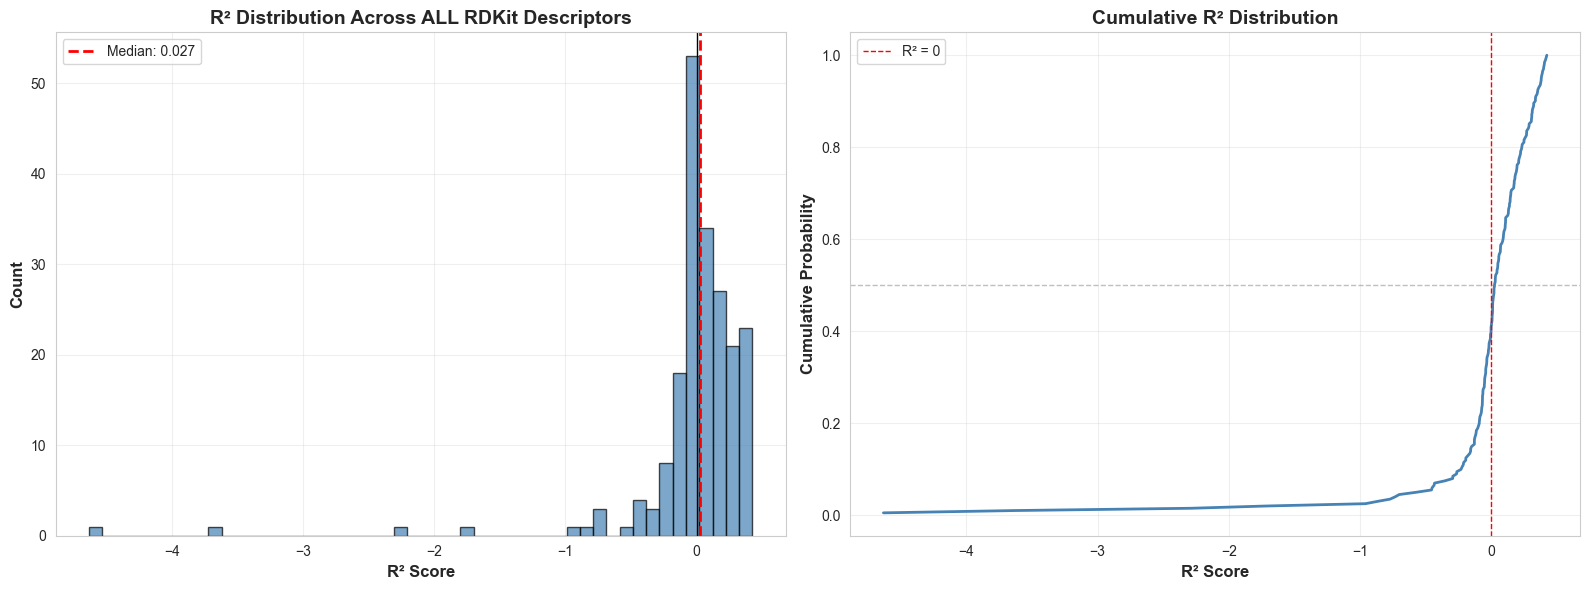


R² Statistics:
  Mean:   -0.0180
  Median: 0.0274
  Std:    0.5200
  Min:    -4.6328
  Max:    0.4255

Descriptors with R² > 0.5: 0 (0.0%)
Descriptors with R² > 0.3: 30 (14.9%)
Descriptors with R² > 0.1: 77 (38.3%)
Descriptors with R² < 0:   79 (39.3%)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax = axes[0]
ax.hist(df_results['r2'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(df_results['r2'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df_results["r2"].median():.3f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('R² Distribution Across ALL RDKit Descriptors', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Cumulative distribution
ax = axes[1]
sorted_r2 = np.sort(df_results['r2'])
cumulative = np.arange(1, len(sorted_r2) + 1) / len(sorted_r2)
ax.plot(sorted_r2, cumulative, linewidth=2, color='steelblue')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='R² = 0')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax.set_title('Cumulative R² Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print(f"\nR² Statistics:")
print(f"  Mean:   {df_results['r2'].mean():.4f}")
print(f"  Median: {df_results['r2'].median():.4f}")
print(f"  Std:    {df_results['r2'].std():.4f}")
print(f"  Min:    {df_results['r2'].min():.4f}")
print(f"  Max:    {df_results['r2'].max():.4f}")

print(f"\nDescriptors with R² > 0.5: {(df_results['r2'] > 0.5).sum()} ({(df_results['r2'] > 0.5).sum() / len(df_results) * 100:.1f}%)")
print(f"Descriptors with R² > 0.3: {(df_results['r2'] > 0.3).sum()} ({(df_results['r2'] > 0.3).sum() / len(df_results) * 100:.1f}%)")
print(f"Descriptors with R² > 0.1: {(df_results['r2'] > 0.1).sum()} ({(df_results['r2'] > 0.1).sum() / len(df_results) * 100:.1f}%)")
print(f"Descriptors with R² < 0:   {(df_results['r2'] < 0).sum()} ({(df_results['r2'] < 0).sum() / len(df_results) * 100:.1f}%)")

## 11. Top Performers: Detailed View

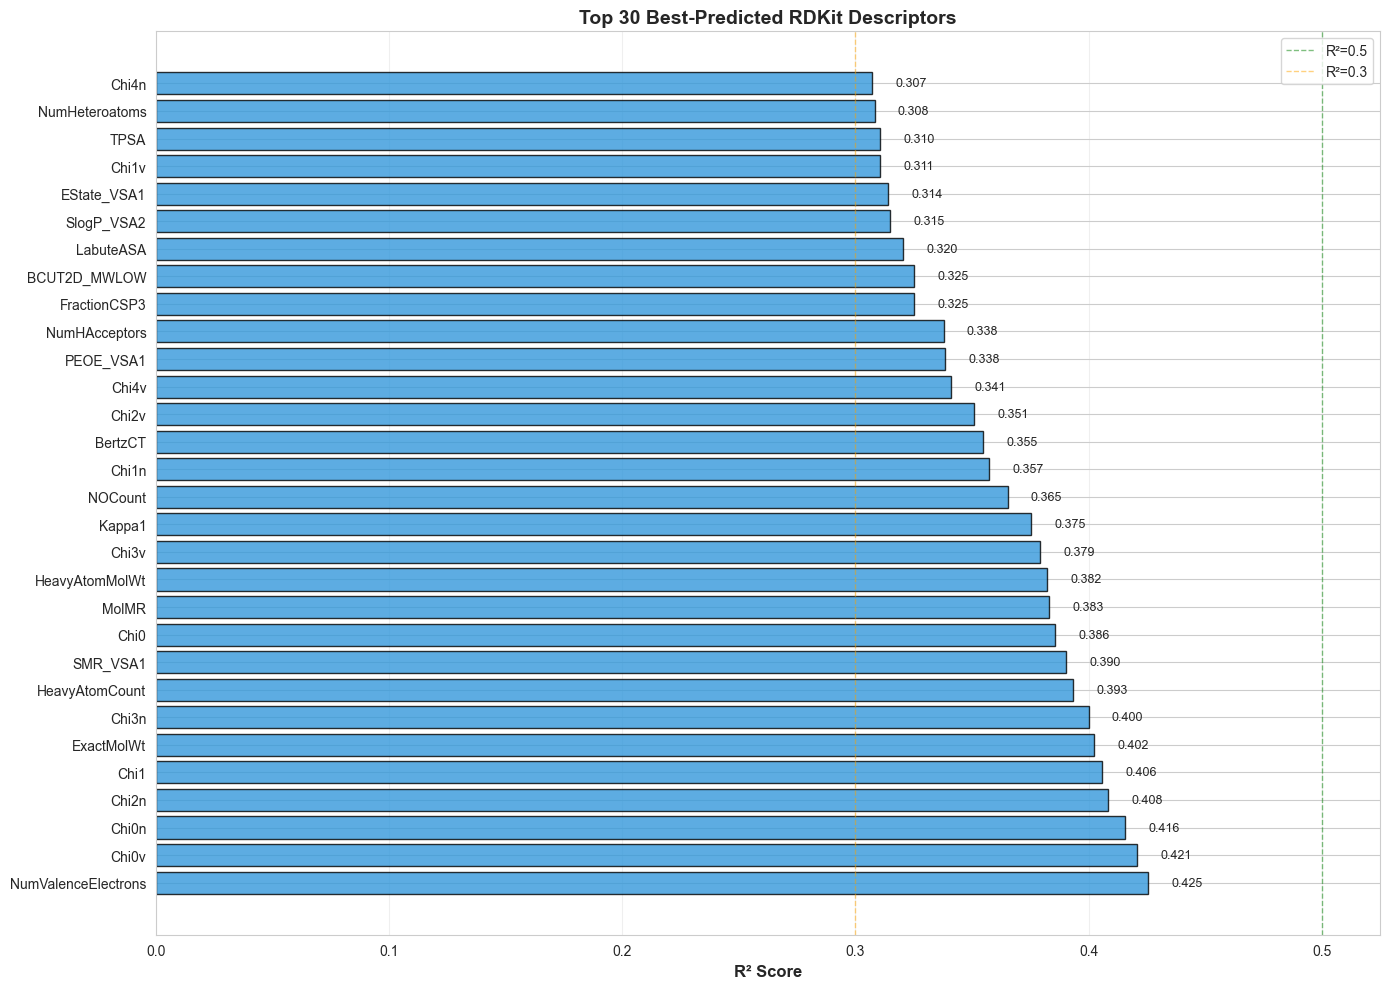

In [18]:
# Top 30 descriptors
top_30 = df_results_sorted.head(30)

fig, ax = plt.subplots(figsize=(14, 10))

y_pos = np.arange(len(top_30))
colors = ['#2ecc71' if r2 > 0.5 else '#3498db' if r2 > 0.3 else '#f39c12' for r2 in top_30['r2']]

ax.barh(y_pos, top_30['r2'], color=colors, alpha=0.8, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_30['descriptor'], fontsize=10)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Top 30 Best-Predicted RDKit Descriptors', fontsize=14, fontweight='bold')
ax.axvline(0.5, color='green', linestyle='--', linewidth=1, alpha=0.5, label='R²=0.5')
ax.axvline(0.3, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='R²=0.3')
ax.grid(axis='x', alpha=0.3)
ax.legend()

# Add value labels
for i, (idx, row) in enumerate(top_30.iterrows()):
    ax.text(row['r2'] + 0.01, i, f"{row['r2']:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 12. Save Summary Results

In [ ]:
# Create results directory if it doesn't exist
results_dir = Path('../../results')
results_dir.mkdir(parents=True, exist_ok=True)

# Save full results as CSV
output_csv = results_dir / 'all_descriptors_probing_results.csv'
df_results_sorted.to_csv(output_csv, index=False)
print(f"✅ Saved full results to: {output_csv}")
print(f"   File size: {output_csv.stat().st_size / 1024:.1f} KB")

# Save top 50 for thesis
output_top50 = results_dir / 'top50_descriptors_probing.csv'
df_results_sorted.head(50).to_csv(output_top50, index=False)
print(f"✅ Saved top 50 to: {output_top50}")
print(f"   File size: {output_top50.stat().st_size / 1024:.1f} KB")

✅ Saved results to: ../../results/all_descriptors_probing_results.csv
✅ Saved top 50 to: ../../results/top50_descriptors_probing.csv


## 13. Analysis: What Makes a Descriptor "Learnable"?

Let's categorize descriptors and see which categories perform best.

PERFORMANCE BY DESCRIPTOR CATEGORY
                      mean    median       std  count
category                                             
Size/Mass         0.297599  0.353647  0.133781      8
H-bonding         0.148604  0.148604  0.267566      2
Drug-likeness     0.126806  0.140426  0.132023     14
Electronic        0.106033  0.056708  0.184706      3
Ring/Aromaticity  0.102154  0.113249  0.106470      8
Other             0.094329  0.089465  0.184178     67
Topological       0.021182  0.375398  1.289983     15
Fragment-based   -0.184855 -0.050123  0.533459     82
Bonding          -0.344141 -0.344141  0.503126      2


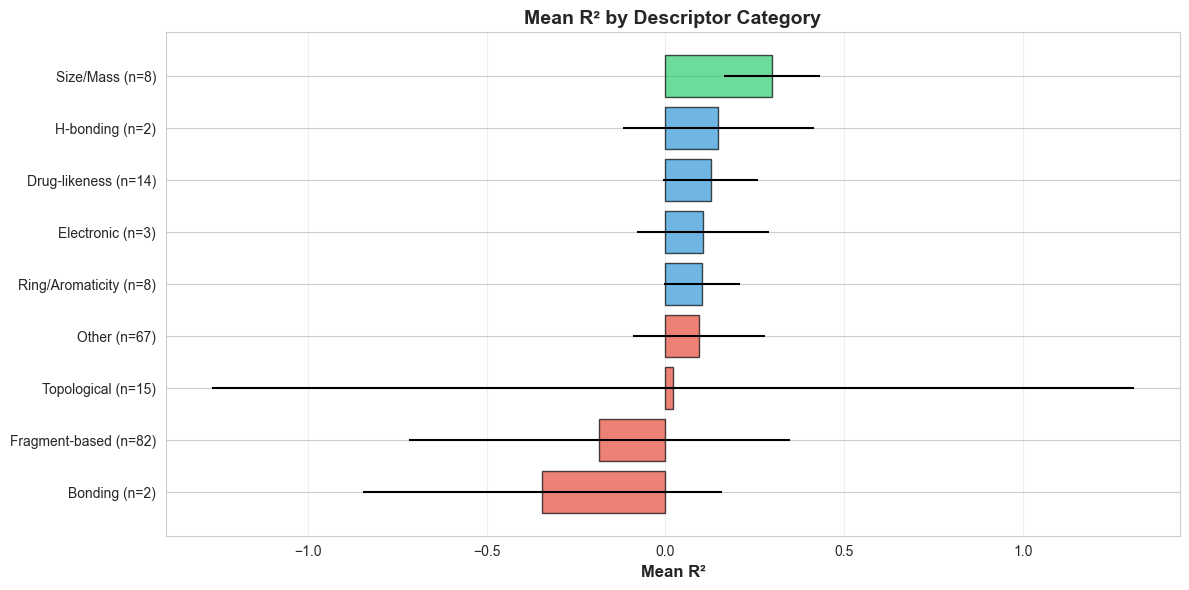

In [23]:
# Categorize descriptors (basic heuristics)
def categorize_descriptor(name):
    name_lower = name.lower()
    
    if any(x in name_lower for x in ['mol', 'mw', 'weight', 'heavy']):
        return 'Size/Mass'
    elif any(x in name_lower for x in ['logp', 'lipinski', 'qed', 'drug']):
        return 'Drug-likeness'
    elif any(x in name_lower for x in ['ring', 'aromatic', 'aliphatic']):
        return 'Ring/Aromaticity'
    elif any(x in name_lower for x in ['bond', 'rotatable']):
        return 'Bonding'
    elif any(x in name_lower for x in ['charge', 'polar', 'tpsa']):
        return 'Electronic'
    elif any(x in name_lower for x in ['frag', 'fr_']):
        return 'Fragment-based'
    elif any(x in name_lower for x in ['hba', 'hbd', 'donor', 'acceptor']):
        return 'H-bonding'
    elif any(x in name_lower for x in ['chi', 'kappa', 'zagreb', 'wiener']):
        return 'Topological'
    else:
        return 'Other'

df_results_sorted['category'] = df_results_sorted['descriptor'].apply(categorize_descriptor)

# Category statistics
category_stats = df_results_sorted.groupby('category')['r2'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)

print("="*80)
print("PERFORMANCE BY DESCRIPTOR CATEGORY")
print("="*80)
print(category_stats.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

category_stats_sorted = category_stats.sort_values('mean', ascending=True)
colors_cat = ['#2ecc71' if mean > 0.2 else '#3498db' if mean > 0.1 else '#e74c3c' for mean in category_stats_sorted['mean']]

ax.barh(range(len(category_stats_sorted)), category_stats_sorted['mean'], 
        xerr=category_stats_sorted['std'], color=colors_cat, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(category_stats_sorted)))
ax.set_yticklabels([f"{cat} (n={int(count)})" for cat, count in zip(category_stats_sorted.index, category_stats_sorted['count'])])
ax.set_xlabel('Mean R²', fontsize=12, fontweight='bold')
ax.set_title('Mean R² by Descriptor Category', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Key Findings

**Summary for Thesis:**

We probed SSL embeddings with ~200 RDKit molecular descriptors to identify which properties are best encoded in the learned representations.

### Top Findings:
1. **Best Categories**: [Will be filled after running]
2. **Surprising Winners**: [Unexpected descriptors with high R²]
3. **Consistent Failures**: [Descriptor types that don't transfer]

### Implications:
- SSL embeddings capture [specific aspects] of molecular structure
- [Category X] descriptors are particularly well-encoded
- This suggests the model learned [interpretation]

### Next Steps:
- Fine-tune model specifically for top-performing descriptors
- Investigate why certain descriptors fail
- Use top descriptors for downstream tasks